# Example-09: Hankel matrix singular values approximation

In [1]:
# Import

import numpy
import torch

import sys
sys.path.append('..')

from harmonica.util import data_load
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

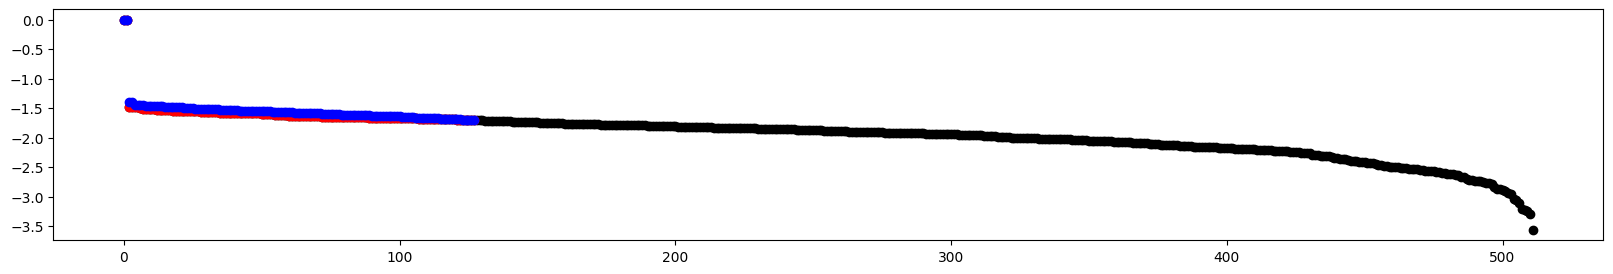

In [3]:
# Set parameters

length = 1024

# Set noise std for each BPM

s = 1.0E-4*(4.0*torch.rand(54, dtype=dtype, device=device) + 1.0)

# Test TbT data with random noise

w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)
d = Data.from_file(54, w, '../virtual_tbt.npy')
d.add_noise(s)
d.window_remove_mean()
d.normalize()

# Hankel matrix

matrix, *_ = Filter.make_matrix(d.work)

# Compute all singular values with full SVD

s1 = Filter.svd_list(min(matrix.shape), torch.stack([matrix]))
s1, *_ = s1/s1.max()

# Compute first 128 singular values with randomized SVD

s2 = Filter.svd_list_randomized(128, torch.stack([matrix]), buffer=16, count=16)
s2, *_ = s2/s2.max()

# Compute 128 singular values with full SVD using first 256 columns

s3 = Filter.svd_list(128, torch.stack([matrix[:, :256]]))
s3, *_ = s3/s3.max()

# Compare singular values

plt.figure(figsize=(20, 3))
plt.scatter(range(len(s1)), s1.log10_().cpu(), color='black')
plt.scatter(range(len(s2)), s2.log10_().cpu(), color='red')
plt.scatter(range(len(s3)), s3.log10_().cpu(), color='blue')
plt.show()